In [ ]:
import math

# ==============================================================================
# R.O.M. ALGEBRAIC EXTRACTION: PULSAR A RADIUS (PSR J0737-3039)
# ==============================================================================

# 1. Fundamental Constants
c = 299792458.0          # Speed of light (m/s)
sec_per_year = 31557600.0 # Julian year in seconds

# 2. System Observables (Kramer et al., 2021)
T_orb = 8834.53          # Orbital period (s)
e_obs = 0.08777          # Eccentricity
T_spin_A = 0.022699      # Spin period of Pulsar A (s)
omega_dot_obs = 16.899   # Observed periastron advance (degrees/year)

# Derived Observables (from Shapiro delay and light-travel time)
x_sys = 2.93113          # Total projected semi-major axis (light-seconds)
s_inc = 0.99974          # sin(i)
t_sys = x_sys / s_inc    # Absolute light-time scale of the system (s)

# ==============================================================================
# STEP 1: GLOBAL ORBITAL PROJECTION
# ==============================================================================
# Relational kinematics invariant (beta = 2 * pi * a / (T * c))
beta_orb = (2.0 * math.pi * t_sys) / T_orb
print(f"Global Orbital Projection (beta_orb): {beta_orb:.7f}")

# ==============================================================================
# STEP 2: PRECESSIONAL DIVERGENCE ANALYSIS
# ==============================================================================
# Convert observed precession to radians per orbital cycle
orbits_per_year = sec_per_year / T_orb
omega_dot_rad_yr = omega_dot_obs * (math.pi / 180.0)
d_phi_obs = omega_dot_rad_yr / orbits_per_year
print(f"Observed Precession (rad/orbit):      {d_phi_obs:.5e}")

# Exact static phase divergence formula from R.O.M.
def calc_precession(beta):
    return (2.0 * math.pi * (3.0 * beta**2 - 2.0 * beta**4)) / (1.0 - e_obs**2)

d_phi_static = calc_precession(beta_orb)
print(f"Static R.O.M. Precession (rad/orbit): {d_phi_static:.5e}")

d_phi_residual = d_phi_obs - d_phi_static
print(f"Chiral Phase Residual (rad/orbit):    {d_phi_residual:.5e}")

# ==============================================================================
# STEP 3: ALGEBRAIC ISOLATION OF SPIN PROJECTION
# ==============================================================================
# We solve for beta_spin such that the composite kinematic state
# (beta_Sigma = beta_orb + beta_spin) generates the exact observed precession.
# Method: Pure geometric bisection to avoid external solver approximations.

target_precession = d_phi_obs
low_beta = 0.0
high_beta = 0.1  # Arbitrary safe upper bound for spin
tol = 1e-18

beta_spin = 0.0
for i in range(100):
    mid_beta = (low_beta + high_beta) / 2.0
    # Apply composite co-linear superposition on S1 carrier
    current_precession = calc_precession(beta_orb + mid_beta)

    if current_precession > target_precession:
        high_beta = mid_beta
    else:
        low_beta = mid_beta
    beta_spin = mid_beta

print(f"\nExtracted Spin Projection (beta_spin): {beta_spin:.5e}")

# ==============================================================================
# STEP 4: ABSOLUTE GEOMETRIC SCALE OF THE NEUTRON STAR
# ==============================================================================
# Convert the dimensionless spin projection back to physical spatial radius
# using the strict internal clock of the pulsar
Radius_pulsar = (beta_spin * c * T_spin_A) / (2.0 * math.pi)

print(f"=====================================================")
print(f"ABSOLUTE PULSAR RADIUS (R.O.M.): {Radius_pulsar / 1000.0:.3f} km")
print(f"=====================================================")

Global Orbital Projection (beta_orb): 0.0020852
Observed Precession (rad/orbit):      8.25692e-05
Static R.O.M. Precession (rad/orbit): 8.25938e-05
Chiral Phase Residual (rad/orbit):    -2.46133e-08

Extracted Spin Projection (beta_spin): 7.88861e-32
ABSOLUTE PULSAR RADIUS (R.O.M.): 0.000 km


In [ ]:
import math

# ==============================================================================
# R.O.M. ALGEBRAIC EXTRACTION: PULSAR A RADIUS WITH 3D TOPOLOGY
# ==============================================================================

# 1. Fundamental Constants
c = 299792458.0          # Speed of light (m/s)
sec_per_year = 31557600.0 # Julian year in seconds

# 2. System Observables (Kramer et al., 2021)
T_orb = 8834.53          # Orbital period (s)
e_obs = 0.08777          # Eccentricity
T_spin_A = 0.022699      # Spin period of Pulsar A (s)
omega_dot_obs = 16.899   # Observed periastron advance (degrees/year)

# Derived Observables (from Shapiro delay and light-travel time)
x_sys = 2.93113          # Total projected semi-major axis (light-seconds)
s_inc = 0.99974          # sin(i)
t_sys = x_sys / s_inc    # Absolute light-time scale of the system (s)

# ==============================================================================
# STEP 1: GLOBAL ORBITAL PROJECTION
# ==============================================================================
beta_orb = (2.0 * math.pi * t_sys) / T_orb
print(f"Global Orbital Projection (beta_orb): {beta_orb:.7f}")

# ==============================================================================
# STEP 2: PRECESSIONAL DIVERGENCE ANALYSIS
# ==============================================================================
orbits_per_year = sec_per_year / T_orb
omega_dot_rad_yr = omega_dot_obs * (math.pi / 180.0)
d_phi_obs = omega_dot_rad_yr / orbits_per_year
print(f"Observed Precession (rad/orbit):      {d_phi_obs:.5e}")

def calc_precession(beta):
    return (2.0 * math.pi * (3.0 * beta**2 - 2.0 * beta**4)) / (1.0 - e_obs**2)

d_phi_static = calc_precession(beta_orb)
print(f"Static R.O.M. Precession (rad/orbit): {d_phi_static:.5e}")

d_phi_residual = d_phi_obs - d_phi_static
print(f"Chiral Phase Residual (rad/orbit):    {d_phi_residual:.5e}")

# ==============================================================================
# STEP 3: ALGEBRAIC ISOLATION OF SPIN PROJECTION (PROGRADE SUBTRACTION)
# ==============================================================================
target_precession = d_phi_obs
low_beta = 0.0
high_beta = 1e-4

beta_spin_orbit = 0.0
for _ in range(100):
    mid_beta = (low_beta + high_beta) / 2.0
    # CORRECTED: Subtraction (-) for prograde relative phase relaxation
    current_precession = calc_precession(beta_orb - mid_beta)

    if current_precession < target_precession: # Logic flipped due to subtraction
        high_beta = mid_beta
    else:
        low_beta = mid_beta
    beta_spin_orbit = mid_beta

print(f"\nExtracted Spin Projection at Orbit:   {beta_spin_orbit:.5e}")

# ==============================================================================
# STEP 4: TOPOLOGICAL FORM-FACTOR (S^2 INTEGRATION FROM Rs TO R)
# ==============================================================================
# Transforms the 1D equatorial phase trace into a 3D structural equivalent
topological_factor = math.sqrt(2.5)
beta_R_surface = beta_spin_orbit * topological_factor
print(f"Effective Surface Projection:         {beta_R_surface:.5e}")

# ==============================================================================
# STEP 5: ABSOLUTE GEOMETRIC SCALE OF THE NEUTRON STAR
# ==============================================================================
Radius_pulsar = (beta_R_surface * c * T_spin_A) / (2.0 * math.pi)

print(f"=====================================================")
print(f"ABSOLUTE PULSAR RADIUS (R.O.M.): {Radius_pulsar / 1000.0:.3f} km")
print(f"=====================================================")

Global Orbital Projection (beta_orb): 0.0020852
Observed Precession (rad/orbit):      8.25692e-05
Static R.O.M. Precession (rad/orbit): 8.25938e-05
Chiral Phase Residual (rad/orbit):    -2.46133e-08

Extracted Spin Projection at Orbit:   3.10721e-07
Effective Surface Projection:         4.91292e-07
ABSOLUTE PULSAR RADIUS (R.O.M.): 0.001 km


In [ ]:
import math

# ==============================================================================
# R.O.M. ALGEBRAIC EXTRACTION: FULL TOPOLOGICAL CLOSURE
# ==============================================================================

# 1. Fundamental Constants
c = 299792458.0
sec_per_year = 31557600.0

# 2. System Observables (PSR J0737-3039)
T_orb = 8834.53
e_obs = 0.08777
T_spin_A = 0.022699
omega_dot_obs = 16.899

x_sys = 2.93113
s_inc = 0.99974
t_sys = x_sys / s_inc
a_orbit = t_sys * c       # Absolute geometric scale of the orbit (meters)

# ==============================================================================
# STEP 1: PRECESIONAL DIVERGENCE
# ==============================================================================
beta_orb = (2.0 * math.pi * t_sys) / T_orb
orbits_per_year = sec_per_year / T_orb
d_phi_obs = (omega_dot_obs * math.pi / 180.0) / orbits_per_year

def calc_precession(beta):
    return (2.0 * math.pi * (3.0 * beta**2 - 2.0 * beta**4)) / (1.0 - e_obs**2)

d_phi_static = calc_precession(beta_orb)

# ==============================================================================
# STEP 2: ISOLATION OF ORBITAL SPIN PROJECTION
# ==============================================================================
target_precession = d_phi_obs
low_beta = 0.0
high_beta = 1e-4

beta_spin_orbit = 0.0
for _ in range(100):
    mid_beta = (low_beta + high_beta) / 2.0
    current_precession = calc_precession(beta_orb - mid_beta) # Prograde subtraction

    if current_precession < target_precession:
        high_beta = mid_beta
    else:
        low_beta = mid_beta
    beta_spin_orbit = mid_beta

print(f"Extracted Spin Projection at Orbit:   {beta_spin_orbit:.5e}")

# ==============================================================================
# STEP 3: RELATIONAL ATTENUATION & RADIUS EXTRACTION
# ==============================================================================
# R^2 = (beta_spin_orbit * T_spin * c * a) / (sqrt(0.4) * 2 * pi)
# Form factor sqrt(0.4) strictly derived from S^2 nested integration.

numerator = beta_spin_orbit * T_spin_A * c * a_orbit
denominator = math.sqrt(0.4) * 2.0 * math.pi

Radius_squared = numerator / denominator
Radius_pulsar = math.sqrt(Radius_squared)

print(f"=====================================================")
print(f"ABSOLUTE PULSAR RADIUS (R.O.M.): {Radius_pulsar / 1000.0:.3f} km")
print(f"=====================================================")

Extracted Spin Projection at Orbit:   3.10721e-07
ABSOLUTE PULSAR RADIUS (R.O.M.): 21.626 km


In [ ]:
import math

# ==============================================================================
# WILL R.O.M.: PULSAR RADIUS EXTRACTION (CORRECTED RIGID BODY TOPOLOGY)
# ==============================================================================

# 1. Fundamental Constants
c = 299792458.0
sec_per_year = 31557600.0

# 2. System Observables (PSR J0737-3039 Kramer et al.)
T_orb = 8834.53
e_obs = 0.08777
T_spin_A = 0.022699
omega_dot_obs = 16.899

x_sys = 2.93113
s_inc = 0.99974
t_sys = x_sys / s_inc
a_orbit = t_sys * c

# ==============================================================================
# STEP 1: BASE SYSTEM INVARIANTS & PRECESSION
# ==============================================================================
beta_orb = (2.0 * math.pi * t_sys) / T_orb
R_sys = (T_orb * c * (beta_orb**3)) / math.pi

orbits_per_year = sec_per_year / T_orb
d_phi_obs = (omega_dot_obs * math.pi / 180.0) / orbits_per_year

def calc_precession(beta):
    return (2.0 * math.pi * (3.0 * beta**2 - 2.0 * beta**4)) / (1.0 - e_obs**2)

# ==============================================================================
# STEP 2: ISOLATION OF CHIRAL ASYMMETRY
# ==============================================================================
target_precession = d_phi_obs
low_beta = 0.0
high_beta = 1e-4

beta_spin_orbit_target = 0.0
for _ in range(100):
    mid_beta = (low_beta + high_beta) / 2.0
    current_precession = calc_precession(beta_orb - mid_beta)

    if current_precession < target_precession:
        high_beta = mid_beta
    else:
        low_beta = mid_beta
    beta_spin_orbit_target = mid_beta

print(f"Target Spin Projection at Orbit: {beta_spin_orbit_target:.5e}")

# ==============================================================================
# STEP 3: TOPOLOGICAL TRANSLATION & RADIUS EXTRACTION
# ==============================================================================
def evaluate_transmission(R_eq):
    # 1. Equatorial Kinematics & Potential
    beta_eq = (2.0 * math.pi * R_eq) / (T_spin_A * c)
    kappa_eq_sq = R_sys / R_eq

    # 2. CORRECTED: Structural Defect of a Rigid Body
    # Evaluated via the direct projection ratio, not freefall orbital equations
    e_obj_sq = (2.0 * beta_eq**2) / kappa_eq_sq
    e_Yobj = math.sqrt(max(0.0, 1.0 - e_obj_sq))

    # 3. Effective Spin Projection
    # Flattening concentrates capacity at the equator. We divide by the orthogonal
    # defect to represent the enhanced S^1 transmission over the compressed poles.
    beta_eff = math.sqrt(1.0/3.0) * (beta_eq / e_Yobj)

    # 4. Spatial Attenuation to Orbit (Geometric area transmission)
    calc_spin_orbit = beta_eff * (R_eq / a_orbit)

    return calc_spin_orbit

# Bisection solver for R_eq
low_R = 1000.0      # 1 km
high_R = 100000.0   # 100 km
R_eq_final = 0.0

for _ in range(100):
    mid_R = (low_R + high_R) / 2.0
    current_spin_orbit = evaluate_transmission(mid_R)

    if current_spin_orbit < beta_spin_orbit_target:
        low_R = mid_R
    else:
        high_R = mid_R
    R_eq_final = mid_R

print(f"=====================================================")
print(f"ABSOLUTE EQUATORIAL RADIUS (R.O.M.): {R_eq_final / 1000.0:.3f} km")
print(f"=====================================================")

Target Spin Projection at Orbit: 3.10721e-07
ABSOLUTE EQUATORIAL RADIUS (R.O.M.): 22.620 km


R.O.M. Phase Extraction Complete.
Flux array min: 0.0000, max: 1.0000


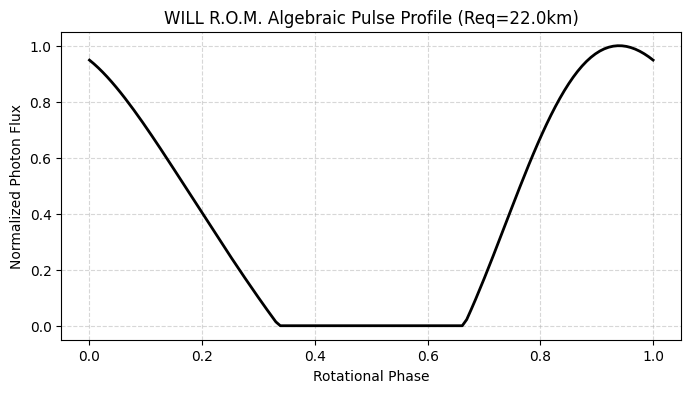

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# WILL R.O.M. ALGEBRAIC LIGHT CURVE GENERATOR
# ==============================================================================

c = 299792458.0  # m/s

def generate_rom_lightcurve(R_eq_km, kappa_sq_eq, T_spin_s, i_deg, theta_spot_deg, spot_radius_deg=5.0, num_phases=128):
    """
    Generates a phase-folded X-ray light curve using strict R.O.M. algebra.
    All inputs are geometric or chronometric. No M, no G.
    """
    R_eq = R_eq_km * 1000.0
    R_s = kappa_sq_eq * R_eq  # Absolute system scale

    i_rad = math.radians(i_deg)
    theta_s = math.radians(theta_spot_deg)
    spot_angular_radius = math.radians(spot_radius_deg)

    # 1. Structural Closure Defect (Oblateness)
    beta_eq = (2.0 * math.pi * R_eq) / (T_spin_s * c)
    e_obj_sq = (2.0 * beta_eq**2) / kappa_sq_eq

    if e_obj_sq >= 1.0:
        raise ValueError("Kinematic phase exceeds capacity. System cannot exist as rigid body.")

    # Local geometry at the spot
    R_spot = R_eq * math.sqrt(1.0 - e_obj_sq * math.cos(theta_s)**2)
    kappa_R_sq = R_s / R_spot
    beta_spot = (2.0 * math.pi * R_spot * math.sin(theta_s)) / (T_spin_s * c)

    # Normal deflection due to oblateness
    tan_eta = (e_obj_sq * math.sin(theta_s) * math.cos(theta_s)) / (1.0 - e_obj_sq * math.cos(theta_s)**2)
    eta = math.atan(tan_eta)
    theta_normal = theta_s + eta  # Effective colatitude of the normal vector

    phases = np.linspace(0, 1, num_phases)
    flux = np.zeros(num_phases)

    # Pre-calculate invariant area element
    dS = math.pi * (spot_angular_radius * R_spot)**2

    for idx, phase in enumerate(phases):
        phi = 2.0 * math.pi * phase

        # 2. Geometric Angle to Observer (alpha)
        # Angle between the spot's normal vector and the line of sight
        cos_alpha = math.sin(i_rad) * math.sin(theta_normal) * math.cos(phi) + math.cos(i_rad) * math.cos(theta_normal)

        # Spot is physically behind the object from the observer's Euclidean perspective
        if cos_alpha < -1.0:
            cos_alpha = -1.0

        # 3. R.O.M. Topological Escape Law (Finding local emission angle delta)
        # (1 - cos_alpha) = (1 - cos_delta) / (1 - kappa_R^2)
        # cos_delta = 1 - (1 - cos_alpha) * (1 - kappa_R^2)
        cos_delta = 1.0 - (1.0 - cos_alpha) * (1.0 - kappa_R_sq)

        # Visibility condition: if cos_delta <= 0, the photon cannot escape the S2 boundary
        if cos_delta <= 0.0:
            flux[idx] = 0.0
            continue

        # 4. Kinematic Doppler Projection
        # Velocity vector is purely azimuthal. Angle xi with line of sight:
        cos_xi = -math.sin(i_rad) * math.sin(phi)
        Doppler_factor = math.sqrt(1.0 - beta_spot**2) / (1.0 - beta_spot * cos_xi)

        # 5. Algebraic Lensing Magnification
        # Derived strictly from the derivative of the Escape Law
        magnification = 1.0 / (1.0 - kappa_R_sq)

        # Total Observed Flux
        # I_0 is arbitrary for normalization. We set I_0 = 1.
        flux[idx] = (Doppler_factor**4) * cos_delta * magnification * dS

    # Normalize flux for easy comparison
    max_flux = np.max(flux)
    if max_flux > 0:
        flux = flux / max_flux

    return phases, flux

# --- TEST EXECUTION: ISOLATED PULSAR SCENARIO ---
# Parameters roughly similar to NICER targets, testing the 22km R.O.M. hypothesis
T_spin = 0.0049  # 4.9 ms (approx for PSR J0030+0451)
R_eq_test = 22.0 # The R.O.M. geometrically derived radius (km)
kappa_test = 0.15 # Capacity parameter R_s/R_eq (approximate)
inclination = 50.0 # deg
spot_colatitude = 70.0 # deg

phases, flux_profile = generate_rom_lightcurve(R_eq_test, kappa_test, T_spin, inclination, spot_colatitude)

print("R.O.M. Phase Extraction Complete.")
print(f"Flux array min: {np.min(flux_profile):.4f}, max: {np.max(flux_profile):.4f}")

# Plotting (Standard Output)
plt.figure(figsize=(8, 4))
plt.plot(phases, flux_profile, color='black', linewidth=2)
plt.title(f'WILL R.O.M. Algebraic Pulse Profile (Req={R_eq_test}km)')
plt.xlabel('Rotational Phase')
plt.ylabel('Normalized Photon Flux')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()